Machine Learning Model Comparison Project
-----------
-----------
-By Connor Bailey

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def median_impute(df, numeric_cols):        #Helper function to fill in missing values/NaN
    df = df.copy()
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    return df

def load_and_clean_penguin_data(     #Self explanatory
    csv_path: str,
    scale_features: bool = True,
    drop_outliers: bool = False
):
    df = pd.read_csv(csv_path)

    df = df.drop(columns=["sex"], errors="ignore")      #Sex info is irrelevent, getting rid of it

    df = df.dropna(how="all")           #removing empty/duplicate rows
    df = df.drop_duplicates()

    y = df["species"]                   #Setting our target to Y
    X = df.drop(columns=["species"])

    numeric_cols = X.select_dtypes(include=[np.number]).columns         #Median Imputation from early development, I'm scared to touch this
    X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

    if drop_outliers:       #IQR to handle outliers
        mask = np.ones(len(X), dtype=bool)
        for col in numeric_cols:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            mask &= (X[col] >= lower) & (X[col] <= upper)

        X = X[mask]
        y = y[mask]

    numeric_cols = X.select_dtypes(include=[np.number]).columns
    
    X = median_impute(X, numeric_cols)      #Imputing after masking

    stats = X[numeric_cols].agg(        #Stats display
        ["mean", "std", "min", "max", "median"]
    ).T

    print(stats)

    return X, y, numeric_cols, df


Calling function and printing stats
---------

In [2]:
X, y, numeric_cols, df = load_and_clean_penguin_data("penguins.csv/penguins.csv")       

X.head(), y.head()


                          mean         std     min     max   median
body_mass_g        4199.854651  796.441142  2700.0  6300.0  4050.00
culmen_depth_mm      17.156395    1.962317    13.1    21.5    17.30
culmen_length_mm     43.925000    5.443792    32.1    59.6    44.45
flipper_length_mm   200.892442   14.023826   172.0   231.0   197.00
island                0.662791    0.726194     0.0     2.0     1.00


(   body_mass_g  culmen_depth_mm  culmen_length_mm  flipper_length_mm  island
 0       4200.0             13.9              45.5              210.0     0.0
 1       4650.0             13.7              40.9              214.0     0.0
 2       5300.0             14.2              51.3              218.0     0.0
 3       5650.0             15.0              47.8              215.0     0.0
 4       5050.0             15.8              46.3              215.0     0.0,
 0    2.0
 1    2.0
 2    2.0
 3    2.0
 4    2.0
 Name: species, dtype: float64)

Displays mean/min/max/medianvalues and standard deviation

In [3]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(df)

     body_mass_g  culmen_depth_mm  culmen_length_mm  flipper_length_mm  \
0         4200.0             13.9              45.5              210.0   
1         4650.0             13.7              40.9              214.0   
2         5300.0             14.2              51.3              218.0   
3         5650.0             15.0              47.8              215.0   
4         5050.0             15.8              46.3              215.0   
5         4650.0             19.1              39.8              184.0   
6         3900.0             17.5              41.1              190.0   
7         3800.0             19.0              49.5              200.0   
8         3700.0             18.6              41.4              191.0   
9         3725.0             17.0              40.7              190.0   
10        3150.0             18.6              37.9              172.0   
11        3700.0             17.1              36.0              187.0   
12        5550.0             15.0     

^ Debugging cell prints out dataframe

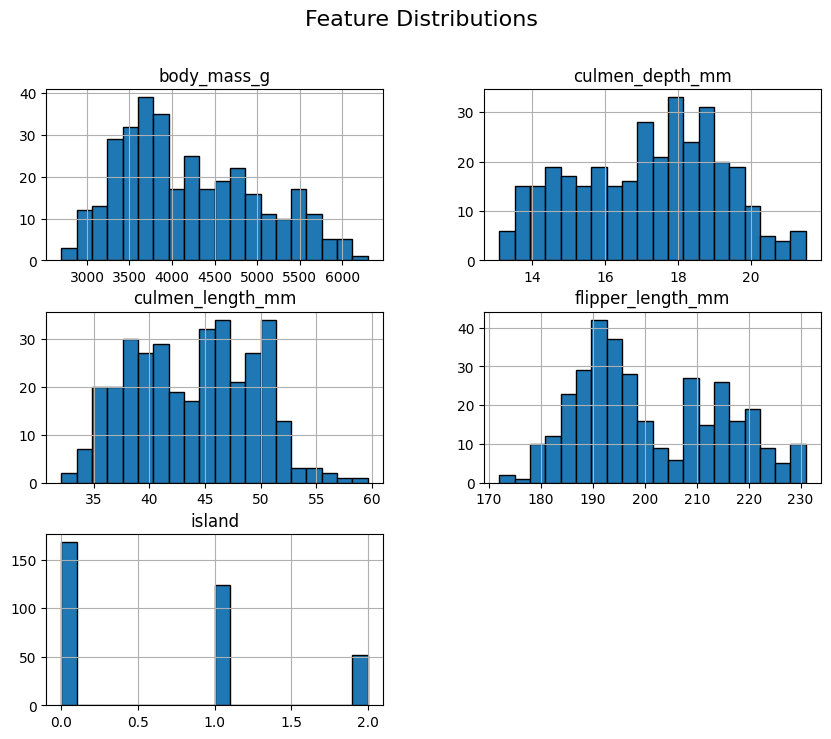

In [4]:
import matplotlib.pyplot as plt

df[numeric_cols].hist(
    bins=20,
    figsize=(10, 8),
    edgecolor="black"
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

^ Histogram for visualization of feature distributions

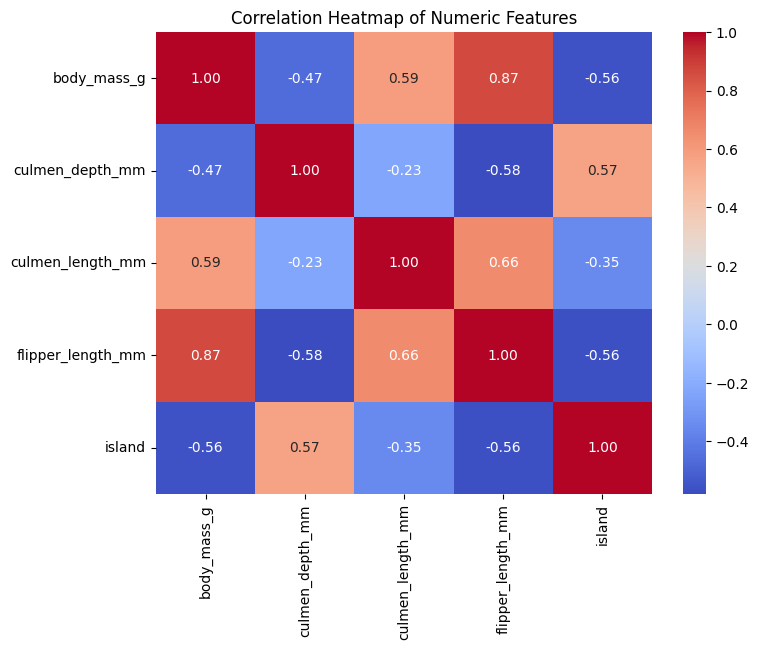

In [ ]:
import seaborn as sns

correlation_matrix = X.corr(numeric_only=True)


plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

^Heatmap helps us interpret how "valuable" each attribute is, closer to 1 = more corrolation

_Heavier specimens are likely to have larger flippers_

Data Splitting
-------------
Dividing data into training and testing groups

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(        
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

                                                                  
imputer = SimpleImputer(strategy="median")       #I found that Imputation after splitting got rid of unwanted NaNs

X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

                   
scaler = StandardScaler()           #We feature scale only the training data

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

Debugging, ignore

In [15]:
print("NaNs in X:", X.isna().sum())
print("NaNs in X_train:", X_train.isna().sum())
print("NaNs in X_test:", X_test.isna().sum())

print("NaNs in y:", y.isna().sum())
print("NaNs in y_train:", y_train.isna().sum())
print("NaNs in y_test:", y_test.isna().sum())

NaNs in X: body_mass_g          0
culmen_depth_mm      0
culmen_length_mm     0
flipper_length_mm    0
island               0
dtype: int64
NaNs in X_train: body_mass_g          0
culmen_depth_mm      0
culmen_length_mm     0
flipper_length_mm    0
island               0
dtype: int64
NaNs in X_test: body_mass_g          0
culmen_depth_mm      0
culmen_length_mm     0
flipper_length_mm    0
island               0
dtype: int64
NaNs in y: 0
NaNs in y_train: 0
NaNs in y_test: 0


Logistic Regression
-------------

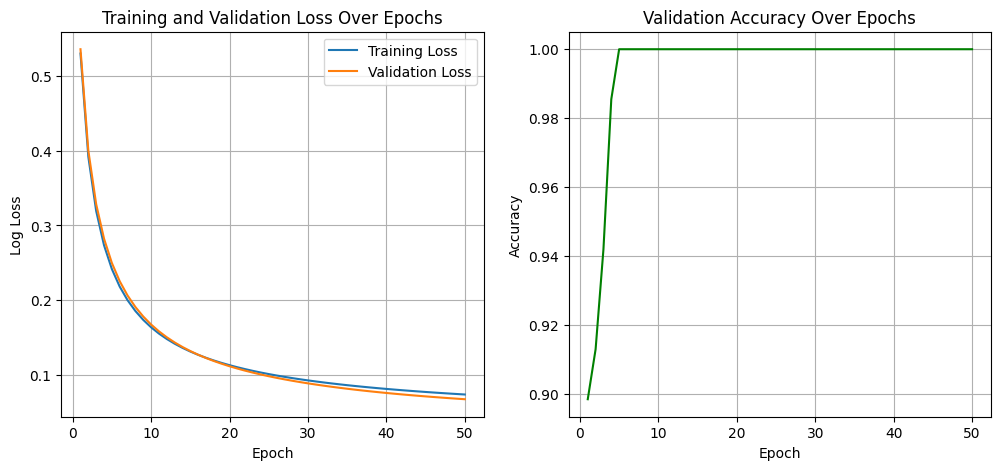


--- Final Metrics (SGDClassifier equivalent) ---
Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        30
         1.0       1.00      1.00      1.00        14
         2.0       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score, classification_report

training_loss_history = []
validation_loss_history = []
accuracy_history = []

model = SGDClassifier(
    loss='log_loss', 
    max_iter=1,          
    shuffle=True, 
    random_state=42,
    learning_rate='constant', 
    eta0=0.01,
    fit_intercept=True
)

n_epochs = 50

classes = np.unique(y_train) 

for epoch in range(1, n_epochs + 1):    #training loop
    model.partial_fit(X_train, y_train, classes=classes)

    y_pred_proba_train = model.predict_proba(X_train)   #loss calculation on training set
    train_loss = log_loss(y_train, y_pred_proba_train, labels=classes)
    training_loss_history.append(train_loss)

    y_pred_proba_test = model.predict_proba(X_test)     #loss calculation on test set
    val_loss = log_loss(y_test, y_pred_proba_test, labels=classes)
    validation_loss_history.append(val_loss)

    y_pred = model.predict(X_test)      #Calculating accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracy_history.append(acc)

plt.figure(figsize=(12, 5))     #plotting

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), training_loss_history, label='Training Loss')
plt.plot(range(1, n_epochs + 1), validation_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), accuracy_history, label='Validation Accuracy', color='green')
plt.title('Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.show()

print("\n--- Final Metrics (SGDClassifier equivalent) ---")     #accuracy report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

^We can see that this model reaches a log loss of 0.1 after ~25 epochs, meaning it is performing well. 

With 100% accuracy after 5 epochs, this model clearly performs well, but this is likely due to the small dataset. We can see in the support column of the final metrics, only 69 samples exist in the dataset.

Random Forest
------------

In [22]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from typing import List, Tuple

def RFmodel(
    X_train, 
    y_train, 
    X_test, 
    y_test, 
    estimator_steps: List[int],
    rf_params: dict,
    title: str = "Random Forest Accuracy vs. Number of Trees"
) -> Tuple[List[int], List[float]]:

    accuracies = []

    estimator_steps = sorted(estimator_steps)

    print(f"Testing n_estimators from {estimator_steps[0]} to {estimator_steps[-1]}...")

    for n_est in estimator_steps:
        rf_model = RandomForestClassifier(      #creating model
            n_estimators=n_est,
            n_jobs=-1,
            **rf_params
        )

        rf_model.fit(X_train, y_train)          #training model

        y_pred = rf_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)       #predicts/tests
        accuracies.append(accuracy)

        print(f"  - n_estimators: {n_est:<4} | Accuracy: {accuracy:.4f}")

    plt.figure(figsize=(10, 6))     #plotting
    plt.plot(estimator_steps, accuracies, marker='o')

    best_idx = accuracies.index(max(accuracies))
    best_n = estimator_steps[best_idx]

    plt.axvline(best_n, linestyle='--', alpha=0.6,
                label=f'Best n_estimators = {best_n}')

    plt.title(title)
    plt.xlabel("Number of Trees")
    plt.ylabel("Accuracy")
    plt.xticks(estimator_steps)
    plt.legend()
    plt.tight_layout()
    plt.show()
    # print("HELLO")
    return estimator_steps, accuracies





Running Random Forest model and printing data


--- Final Metrics (RandomForest 100 Trees) ---
Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        30
         1.0       1.00      1.00      1.00        14
         2.0       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



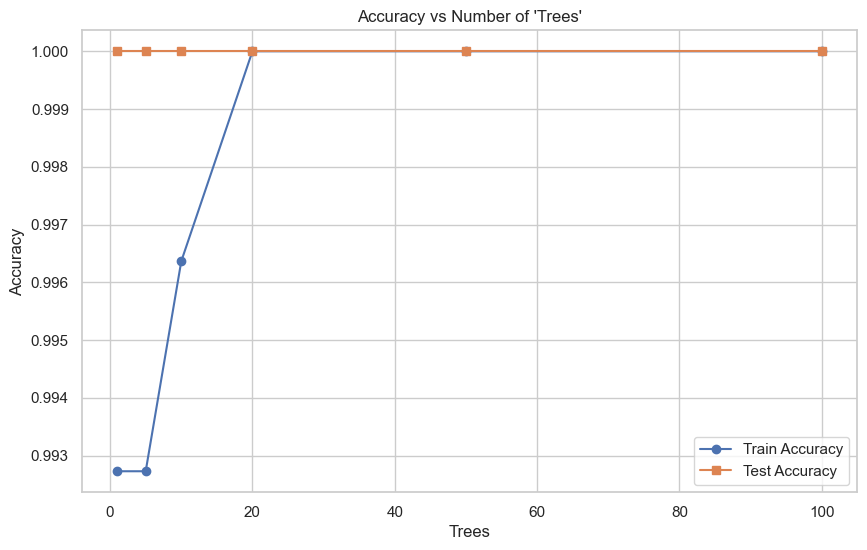

In [29]:
def run_rf_accuracy_plot(X_train,y_train,X_test,y_test):
    
    n_steps = [1, 5, 10, 20, 50, 100]
    rf_params = {"random_state": 42}

    train_accuracies = []
    test_accuracies = []
    final_y_pred = None

    for n in n_steps:
        current_params = rf_params.copy()
        current_params["n_estimators"]=n

        model = RandomForestClassifier(**current_params)
        model.fit(X_train,y_train)
        
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_accuracies.append(accuracy_score(y_train, train_pred))
        test_accuracies.append(accuracy_score(y_test, test_pred))

        if n == 100:
            final_y_pred = test_pred

    if final_y_pred is not None:
        print("\n--- Final Metrics (RandomForest 100 Trees) ---")
        print("Accuracy:", accuracy_score(y_test, final_y_pred))
        print(classification_report(y_test, final_y_pred))

        sns.set_theme(style="whitegrid")
        plt.figure(figsize=(10, 6))
        plt.plot(n_steps, train_accuracies, label="Train Accuracy", marker="o")
        plt.plot(n_steps, test_accuracies, label="Test Accuracy", marker="s")

    plt.title("Accuracy vs Number of 'Trees'")
    plt.xlabel("Trees")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


run_rf_accuracy_plot(X_train, y_train, X_test, y_test)


While 100% accuracy at the first tree may look suspicious, this is actually correct. This may be due to overfitting, as trees can memorize data points on sufficiently small sets.

Neural Network
------------


Neural Network Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        30
         1.0       1.00      1.00      1.00        14
         2.0       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



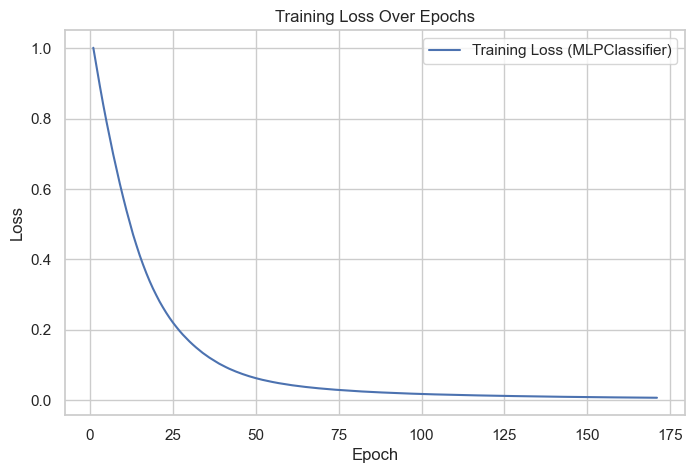

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split 

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42,
)

mlp.fit(X_train, y_train)           #training model

y_pred_mlp = mlp.predict(X_test)

print("\nNeural Network Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

if hasattr(mlp, 'loss_curve_'): 
    training_loss_history = mlp.loss_curve_
    epochs = len(training_loss_history)
    
    plt.figure(figsize=(8, 5))      #plotting training loss
    
    plt.plot(range(1, epochs + 1), training_loss_history, label='Training Loss (MLPClassifier)')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_mlp_history(model_params, X_train, y_train, X_test, y_test, num_epochs=100):       #Training in a loop to plot accuracy
    
    model = MLPClassifier(
        **model_params,
        max_iter=1, 
        warm_start=True 
    )

    train_loss = []
    val_accuracy = []
    
    for epoch in range(1, num_epochs + 1):
        model.fit(X_train, y_train)
        
        if hasattr(model, 'loss_'):     #recording loss
             pass 

        y_pred = model.predict(X_test)      #recording accuracy
        acc = accuracy_score(y_test, y_pred)
        val_accuracy.append(acc)

        if epoch >= model_params['max_iter']:
            break

    train_loss = model.loss_curve_
    
    fig, ax1 = plt.subplots(figsize=(10, 6))        #plotting

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:blue')
    ax1.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()  
    ax2.set_ylabel('Accuracy', color='tab:red')
    ax2.plot(range(1, len(val_accuracy) + 1), val_accuracy, label='Validation Accuracy', color='tab:red', linestyle='--')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.legend(loc='upper right')

    plt.title('MLP Training History: Loss and Accuracy')
    fig.tight_layout() 
    plt.grid(True)
    plt.show()
    
mlp_params = {
    'hidden_layer_sizes': (64, 32),
    'activation': "relu",
    'solver': "adam",
    'max_iter': 1000, 
    'random_state': 42
}

This model is performs similarly to the logistic regression model, 0.1 loss after ~40 iterations

Confusion Matrix
----------------

Here, we can see that all models label data with 100% accuracy

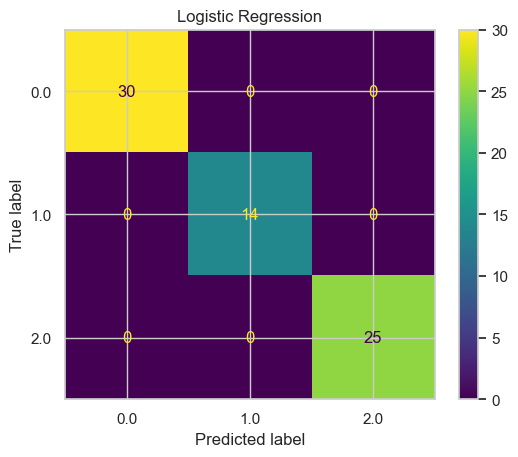

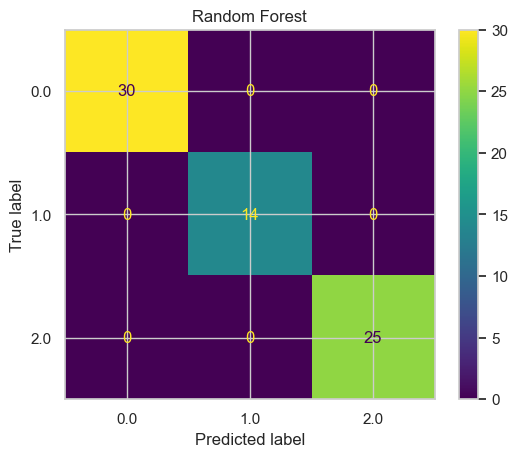

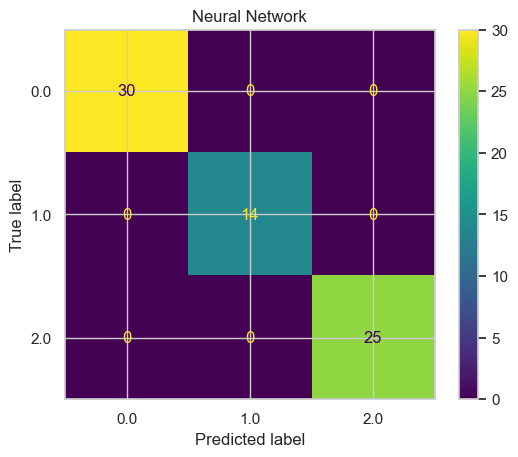

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)


models = {
    "Logistic Regression": y_pred,
    "Random Forest": y_pred_rf,
    "Neural Network": y_pred_mlp
}


for name, preds in models.items():
    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.title(name)
    plt.show()